# Chapter 7: Coordinator-Worker-Delegator Model
## Demo Implementation with Triggerable Failure Modes

This notebook demonstrates the Coordinator-Worker-Delegator architecture pattern and its three primary failure modes:

1. **Context Loss in Delegation Chains** - Information degrades as it passes through hierarchy levels
2. **Coordinator Bottleneck** - Coordinator overwhelmed by parallel Worker results
3. **Delegation Oscillation** - Tasks bounce between Delegators indefinitely

Each failure mode can be triggered deliberately by adjusting configuration parameters.

---
## Setup and Imports

In [2]:
!pip install nest-asyncio

In [3]:
import asyncio
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Any
from enum import Enum
import random
import time
from datetime import datetime

# For Jupyter async support
import nest_asyncio
nest_asyncio.apply()

print("✓ Setup complete")

✓ Setup complete


---
## Core Data Structures

In [4]:
class Role(Enum):
    COORDINATOR = "coordinator"
    DELEGATOR = "delegator"
    WORKER = "worker"

@dataclass
class Task:
    """Represents a task flowing through the system"""
    id: str
    content: str
    context: Dict[str, Any]
    source: str
    delegation_depth: int = 0
    routing_history: List[str] = field(default_factory=list)

    def __post_init__(self):
        if not self.routing_history:
            self.routing_history = []

@dataclass
class Result:
    """Represents a result flowing back up the hierarchy"""
    task_id: str
    content: str
    source: str
    confidence: float
    success: bool
    metadata: Dict[str, Any]
    error_type: Optional[str] = None

print("✓ Data structures defined")

✓ Data structures defined


---
## Base Agent Class

In [5]:
class Agent:
    """Base class for all agents in the hierarchy"""

    def __init__(self, name: str, role: Role, domain: Optional[str] = None, verbose: bool = True):
        self.name = name
        self.role = role
        self.domain = domain
        self.subordinates: List['Agent'] = []
        self.verbose = verbose

    def log(self, message: str):
        if self.verbose:
            timestamp = datetime.now().strftime("%H:%M:%S.%f")[:-3]
            role_symbol = {"coordinator": "🎯", "delegator": "📋", "worker": "⚙️"}[self.role.value]
            print(f"[{timestamp}] {role_symbol} {self.name}: {message}")

    async def process(self, task: Task) -> Result:
        raise NotImplementedError("Subclasses must implement process()")

    def add_subordinate(self, agent: 'Agent'):
        self.subordinates.append(agent)
        self.log(f"Added subordinate: {agent.name}")

print("✓ Base Agent class defined")

✓ Base Agent class defined


---
## Worker Implementation

In [6]:
class Worker(Agent):
    """Leaf node that executes specific tasks"""

    def __init__(self, name: str, domain: str, processing_time: float = 0.5, verbose: bool = True):
        super().__init__(name, Role.WORKER, domain, verbose)
        self.processing_time = processing_time

    async def process(self, task: Task) -> Result:
        self.log(f"Processing task {task.id}")
        self.log(f"Context received: {list(task.context.keys())}")
        self.log(f"Delegation depth: {task.delegation_depth}")

        # Simulate work
        await asyncio.sleep(self.processing_time)

        # Calculate confidence based on context preservation
        expected_context_keys = {'constraint_1', 'constraint_2', 'constraint_3', 'constraint_4', 'constraint_5'}
        received_keys = set(task.context.keys())
        context_ratio = len(received_keys & expected_context_keys) / len(expected_context_keys) if expected_context_keys else 1.0

        confidence = 0.5 + (0.5 * context_ratio)  # 0.5 to 1.0 based on context

        self.log(f"Completed with confidence {confidence:.2f}")

        return Result(
            task_id=task.id,
            content=f"[{self.name}] Analyzed: {task.content[:50]}...",
            source=self.name,
            confidence=confidence,
            success=True,
            metadata={
                "domain": self.domain,
                "context_received": list(task.context.keys()),
                "context_ratio": context_ratio,
                "delegation_depth": task.delegation_depth,
                "processing_time": self.processing_time
            }
        )

print("✓ Worker class defined")

✓ Worker class defined


---
## Delegator Implementation (with Context Loss Mechanism)

In [7]:
class Delegator(Agent):
    """
    Middle layer that decomposes tasks and dispatches to Workers.

    CONTEXT LOSS MECHANISM: Each Delegator loses a fraction of context
    when reformulating tasks for subordinates. This simulates real-world
    information loss in delegation chains.
    """

    def __init__(self, name: str, domain: str,
                 context_preservation: float = 0.8,
                 peer_delegators: List['Delegator'] = None,
                 verbose: bool = True):
        super().__init__(name, Role.DELEGATOR, domain, verbose)
        self.context_preservation = context_preservation
        self.peer_delegators = peer_delegators or []

    async def process(self, task: Task) -> Result:
        self.log(f"Received task {task.id} (depth={task.delegation_depth})")
        self.log(f"Context keys: {list(task.context.keys())}")

        # CONTEXT LOSS: Probabilistically drop context items
        preserved_context = {}
        lost_keys = []
        for key, value in task.context.items():
            if random.random() < self.context_preservation:
                preserved_context[key] = value
            else:
                lost_keys.append(key)

        if lost_keys:
            self.log(f"⚠️ CONTEXT LOSS: Dropped {lost_keys}")

        # Check if we have subordinates
        if not self.subordinates:
            return Result(
                task_id=task.id,
                content=f"No workers available in {self.domain} domain",
                source=self.name,
                confidence=0.0,
                success=False,
                metadata={"error": "no_subordinates"}
            )

        # Decompose task for workers
        subtasks = self._decompose(task, preserved_context)

        # Dispatch to workers
        self.log(f"Dispatching to {len(self.subordinates)} workers")
        results = await asyncio.gather(*[
            worker.process(subtask)
            for worker, subtask in zip(self.subordinates, subtasks)
        ])

        # Aggregate results
        return self._aggregate(task.id, results, lost_keys)

    def _decompose(self, task: Task, context: Dict) -> List[Task]:
        """Break task into subtasks for each worker"""
        return [
            Task(
                id=f"{task.id}-{i}",
                content=f"[Subtask {i}] {task.content}",
                context=context,  # Potentially degraded context!
                source=self.name,
                delegation_depth=task.delegation_depth + 1,
                routing_history=task.routing_history + [self.name]
            )
            for i in range(len(self.subordinates))
        ]

    def _aggregate(self, task_id: str, results: List[Result], lost_context: List[str]) -> Result:
        """Combine worker results"""
        avg_confidence = sum(r.confidence for r in results) / len(results)
        all_succeeded = all(r.success for r in results)

        self.log(f"Aggregated {len(results)} results, avg confidence: {avg_confidence:.2f}")

        return Result(
            task_id=task_id,
            content=f"[{self.name}] Aggregated {len(results)} worker results",
            source=self.name,
            confidence=avg_confidence,
            success=all_succeeded,
            metadata={
                "domain": self.domain,
                "num_workers": len(results),
                "context_lost": lost_context,
                "worker_results": [r.metadata for r in results]
            }
        )

print("✓ Delegator class defined (with context loss mechanism)")

✓ Delegator class defined (with context loss mechanism)


---
## Coordinator Implementation (with Bottleneck Mechanism)

In [8]:
class Coordinator(Agent):
    """
    Top-level agent that decomposes tasks and synthesizes results.

    BOTTLENECK MECHANISM: Limited concurrent processing capacity.
    When results arrive faster than they can be processed, the
    Coordinator becomes a bottleneck.
    """

    def __init__(self, name: str,
                 max_concurrent: int = 5,
                 timeout: float = 10.0,
                 verbose: bool = True):
        super().__init__(name, Role.COORDINATOR, verbose=verbose)
        self.max_concurrent = max_concurrent
        self.timeout = timeout

    async def process(self, task: Task) -> Result:
        self.log(f"Received task: {task.id}")
        self.log(f"Dispatching to {len(self.subordinates)} subordinates")
        self.log(f"Max concurrent: {self.max_concurrent}, Timeout: {self.timeout}s")

        start_time = time.time()

        # BOTTLENECK MECHANISM: Semaphore limits concurrent processing
        semaphore = asyncio.Semaphore(self.max_concurrent)

        async def bounded_process(subordinate: Agent, subtask: Task) -> Result:
            async with semaphore:
                return await subordinate.process(subtask)

        # Create subtasks
        subtasks = [
            Task(
                id=f"{task.id}-{sub.name}",
                content=task.content,
                context=task.context.copy(),
                source=self.name,
                delegation_depth=0,
                routing_history=[self.name]
            )
            for sub in self.subordinates
        ]

        try:
            # Execute with timeout
            results = await asyncio.wait_for(
                asyncio.gather(*[
                    bounded_process(sub, subtask)
                    for sub, subtask in zip(self.subordinates, subtasks)
                ]),
                timeout=self.timeout
            )

            elapsed = time.time() - start_time
            self.log(f"All subordinates completed in {elapsed:.2f}s")

            return self._synthesize(task.id, results, elapsed)

        except asyncio.TimeoutError:
            elapsed = time.time() - start_time
            self.log(f"❌ BOTTLENECK FAILURE: Timeout after {elapsed:.2f}s")

            return Result(
                task_id=task.id,
                content="FAILURE: Coordinator timeout exceeded",
                source=self.name,
                confidence=0.0,
                success=False,
                error_type="bottleneck_timeout",
                metadata={
                    "error": "bottleneck_timeout",
                    "timeout_setting": self.timeout,
                    "elapsed": elapsed,
                    "num_subordinates": len(self.subordinates)
                }
            )

    def _synthesize(self, task_id: str, results: List[Result], elapsed: float) -> Result:
        """Combine all subordinate results into final output"""
        avg_confidence = sum(r.confidence for r in results) / len(results)
        all_succeeded = all(r.success for r in results)

        self.log(f"Synthesized {len(results)} results, avg confidence: {avg_confidence:.2f}")

        return Result(
            task_id=task_id,
            content=f"Final synthesis of {len(results)} domain results",
            source=self.name,
            confidence=avg_confidence,
            success=all_succeeded,
            metadata={
                "num_subordinates": len(results),
                "elapsed_time": elapsed,
                "subordinate_results": [r.metadata for r in results]
            }
        )

print("✓ Coordinator class defined (with bottleneck mechanism)")

✓ Coordinator class defined (with bottleneck mechanism)


---
## Oscillation Detection System

In [9]:
class OscillationDetector:
    """
    Detects when tasks bounce between Delegators indefinitely.

    OSCILLATION MECHANISM: When domain boundaries overlap, a task
    may match multiple domains, causing Delegators to route it
    back and forth.
    """

    def __init__(self, max_hops: int = 10):
        self.max_hops = max_hops
        self.routing_history: Dict[str, List[str]] = {}

    def record_routing(self, task_id: str, from_agent: str, to_agent: str) -> bool:
        """Records a routing decision. Returns True if oscillation detected."""
        if task_id not in self.routing_history:
            self.routing_history[task_id] = []

        history = self.routing_history[task_id]
        route = f"{from_agent}->{to_agent}"
        history.append(route)

        # Check for A->B->A->B pattern
        if len(history) >= 4:
            recent = history[-4:]
            if recent[0] == recent[2] and recent[1] == recent[3]:
                return True

        # Check for max hops exceeded
        if len(history) >= self.max_hops:
            return True

        return False

    def get_history(self, task_id: str) -> List[str]:
        return self.routing_history.get(task_id, [])


class RoutingDelegator(Delegator):
    """
    Delegator that can route tasks to peer Delegators.
    Used to demonstrate oscillation failure mode.
    """

    # Shared detector across all instances
    detector = OscillationDetector()

    def __init__(self, name: str, domain: str,
                 domain_keywords: List[str],
                 verbose: bool = True):
        super().__init__(name, domain, verbose=verbose)
        self.domain_keywords = set(domain_keywords)
        self.peers: List['RoutingDelegator'] = []

    def set_peers(self, peers: List['RoutingDelegator']):
        self.peers = [p for p in peers if p != self]

    def _matches_domain(self, task: Task) -> float:
        """Returns match score (0-1) for how well task matches this domain"""
        task_words = set(task.content.lower().split())
        overlap = len(task_words & self.domain_keywords)
        return overlap / len(self.domain_keywords) if self.domain_keywords else 0

    async def process(self, task: Task) -> Result:
        self.log(f"Evaluating task {task.id}")

        my_score = self._matches_domain(task)
        self.log(f"My domain match score: {my_score:.2f}")

        # Check if a peer is a better match
        for peer in self.peers:
            peer_score = peer._matches_domain(task)
            if peer_score > my_score:
                self.log(f"Routing to {peer.name} (score: {peer_score:.2f})")

                # Check for oscillation
                if self.detector.record_routing(task.id, self.name, peer.name):
                    history = self.detector.get_history(task.id)
                    self.log(f"❌ OSCILLATION DETECTED! History: {history}")

                    return Result(
                        task_id=task.id,
                        content="FAILURE: Delegation oscillation detected",
                        source=self.name,
                        confidence=0.0,
                        success=False,
                        error_type="oscillation",
                        metadata={
                            "error": "oscillation",
                            "routing_history": history,
                            "my_score": my_score,
                            "peer_score": peer_score
                        }
                    )

                return await peer.process(task)

        # Process locally
        self.log(f"Processing locally (best match)")
        return await super().process(task)

print("✓ Oscillation detection system defined")

✓ Oscillation detection system defined


---
# ⚠️ MANDATORY HUMAN DECISION NODE

Before proceeding with the system architecture, you must review and approve the proposed structure.

---

In [10]:
# ================================================================
# MANDATORY HUMAN DECISION NODE
# ================================================================
#
# The AI has proposed the following agent structure for a
# research assistant system:
#
# COORDINATOR: "ResearchCoordinator"
#   ├── DELEGATOR: "ManufacturingDelegator" (domain: manufacturing)
#   │     ├── WORKER: "BatteryResearcher"
#   │     ├── WORKER: "AssemblyResearcher"
#   │     └── WORKER: "MaterialsResearcher"
#   ├── DELEGATOR: "OperationsDelegator" (domain: operations)
#   │     ├── WORKER: "EfficiencyAnalyst"
#   │     └── WORKER: "EmissionsAnalyst"
#   └── DELEGATOR: "DisposalDelegator" (domain: disposal)
#         ├── WORKER: "RecyclingResearcher"
#         └── WORKER: "RegulationsResearcher"
#
# ================================================================
# VERIFICATION CHECKLIST:
# ================================================================
#
# 1. Is the delegation depth appropriate?
#    Current: 2 levels (Coordinator -> Delegator -> Worker)
#    Risk: Each Delegator level can lose ~20% of context
#
#    [ ] YES - 2 levels is appropriate for this use case
#    [ ] NO - Should be flatter (1 level) or deeper (3 levels)
#
# 2. Are Delegator domain scopes non-overlapping?
#    Current domains: manufacturing, operations, disposal
#
#    [ ] YES - Domains are clearly separated
#    [ ] NO - "lifecycle analysis" tasks may oscillate
#
# 3. Can the Coordinator handle parallel results?
#    Current: 3 Delegators returning results
#
#    [ ] YES - 3 concurrent results is manageable
#    [ ] NO - Risk of bottleneck
#
# ================================================================
# YOUR DECISION:
# ================================================================

HUMAN_DECISION = "ACCEPT"  # Options: "ACCEPT", "REJECT", "MODIFY"

# If MODIFY, specify changes:
MODIFICATIONS = """
# Example modifications:
# - Reduce to flat coordination for latency-sensitive tasks
# - Add clearer domain boundaries to prevent oscillation
# - Increase context preservation rate to 0.95
"""

# ================================================================

if HUMAN_DECISION == "ACCEPT":
    print("✅ Human has ACCEPTED the proposed architecture")
    print("   Proceeding with implementation...")
elif HUMAN_DECISION == "REJECT":
    raise ValueError("❌ Human REJECTED the architecture. Please modify and re-run.")
else:
    print(f"⚠️ Human requested MODIFICATIONS:")
    print(MODIFICATIONS)
    print("   Applying modifications before proceeding...")

✅ Human has ACCEPTED the proposed architecture
   Proceeding with implementation...


---
## System Builder

In [11]:
def build_research_system(config: Dict) -> Coordinator:
    """
    Builds the Coordinator-Worker-Delegator system based on config.

    Config options:
    - context_preservation: float (0.0-1.0) - How much context each Delegator preserves
    - coordinator_timeout: float - Seconds before Coordinator times out
    - worker_processing_time: float - Seconds each Worker takes
    - verbose: bool - Whether to print logs
    """
    verbose = config.get('verbose', True)
    context_preservation = config.get('context_preservation', 0.8)
    coordinator_timeout = config.get('coordinator_timeout', 10.0)
    worker_time = config.get('worker_processing_time', 0.5)

    # Create Workers
    manufacturing_workers = [
        Worker("BatteryResearcher", "manufacturing", worker_time, verbose),
        Worker("AssemblyResearcher", "manufacturing", worker_time, verbose),
        Worker("MaterialsResearcher", "manufacturing", worker_time, verbose),
    ]

    operations_workers = [
        Worker("EfficiencyAnalyst", "operations", worker_time, verbose),
        Worker("EmissionsAnalyst", "operations", worker_time, verbose),
    ]

    disposal_workers = [
        Worker("RecyclingResearcher", "disposal", worker_time, verbose),
        Worker("RegulationsResearcher", "disposal", worker_time, verbose),
    ]

    # Create Delegators
    manufacturing_del = Delegator(
        "ManufacturingDelegator", "manufacturing",
        context_preservation, verbose=verbose
    )
    for w in manufacturing_workers:
        manufacturing_del.add_subordinate(w)

    operations_del = Delegator(
        "OperationsDelegator", "operations",
        context_preservation, verbose=verbose
    )
    for w in operations_workers:
        operations_del.add_subordinate(w)

    disposal_del = Delegator(
        "DisposalDelegator", "disposal",
        context_preservation, verbose=verbose
    )
    for w in disposal_workers:
        disposal_del.add_subordinate(w)

    # Create Coordinator
    coordinator = Coordinator(
        "ResearchCoordinator",
        max_concurrent=5,
        timeout=coordinator_timeout,
        verbose=verbose
    )
    coordinator.add_subordinate(manufacturing_del)
    coordinator.add_subordinate(operations_del)
    coordinator.add_subordinate(disposal_del)

    return coordinator

print("✓ System builder defined")

✓ System builder defined


---
# Demo 1: Normal Operation

First, let's see the system working correctly.

In [12]:
# Normal operation configuration
normal_config = {
    'context_preservation': 0.95,  # High context preservation
    'coordinator_timeout': 10.0,   # Generous timeout
    'worker_processing_time': 0.3, # Fast workers
    'verbose': True
}

# Build system
coordinator = build_research_system(normal_config)

# Create task with full context
task = Task(
    id="task-001",
    content="Compare environmental impact of EVs vs hydrogen fuel cells",
    context={
        "constraint_1": "Focus on past 3 years",
        "constraint_2": "Include manufacturing phase",
        "constraint_3": "Include operational phase",
        "constraint_4": "Include disposal phase",
        "constraint_5": "Cite peer-reviewed sources"
    },
    source="user"
)

print("="*60)
print("DEMO 1: NORMAL OPERATION")
print("="*60)

# Run the system
result = asyncio.run(coordinator.process(task))

print("\n" + "="*60)
print("RESULT:")
print(f"  Success: {result.success}")
print(f"  Confidence: {result.confidence:.2f}")
print(f"  Error Type: {result.error_type}")
print("="*60)

[20:38:11.484] 📋 ManufacturingDelegator: Added subordinate: BatteryResearcher
[20:38:11.484] 📋 ManufacturingDelegator: Added subordinate: AssemblyResearcher
[20:38:11.484] 📋 ManufacturingDelegator: Added subordinate: MaterialsResearcher
[20:38:11.484] 📋 OperationsDelegator: Added subordinate: EfficiencyAnalyst
[20:38:11.484] 📋 OperationsDelegator: Added subordinate: EmissionsAnalyst
[20:38:11.484] 📋 DisposalDelegator: Added subordinate: RecyclingResearcher
[20:38:11.484] 📋 DisposalDelegator: Added subordinate: RegulationsResearcher
[20:38:11.484] 🎯 ResearchCoordinator: Added subordinate: ManufacturingDelegator
[20:38:11.484] 🎯 ResearchCoordinator: Added subordinate: OperationsDelegator
[20:38:11.484] 🎯 ResearchCoordinator: Added subordinate: DisposalDelegator
DEMO 1: NORMAL OPERATION
[20:38:11.486] 🎯 ResearchCoordinator: Received task: task-001
[20:38:11.486] 🎯 ResearchCoordinator: Dispatching to 3 subordinates
[20:38:11.486] 🎯 ResearchCoordinator: Max concurrent: 5, Timeout: 10.0s
[20

---
# Demo 2: Trigger Context Loss Failure

By reducing context preservation, we can observe information loss through the delegation chain.

In [13]:
# Context loss configuration
context_loss_config = {
    'context_preservation': 0.4,   # LOW - 60% context lost per level!
    'coordinator_timeout': 10.0,
    'worker_processing_time': 0.3,
    'verbose': True
}

# Build system
coordinator = build_research_system(context_loss_config)

# Same task
task = Task(
    id="task-002",
    content="Compare environmental impact of EVs vs hydrogen fuel cells",
    context={
        "constraint_1": "Focus on past 3 years",
        "constraint_2": "Include manufacturing phase",
        "constraint_3": "Include operational phase",
        "constraint_4": "Include disposal phase",
        "constraint_5": "Cite peer-reviewed sources"
    },
    source="user"
)

print("="*60)
print("DEMO 2: CONTEXT LOSS FAILURE")
print("Config: context_preservation=0.4 (60% loss per level)")
print("="*60)

# Run multiple times to see variance
for i in range(3):
    print(f"\n--- Run {i+1} ---")
    task.id = f"task-002-run{i}"
    result = asyncio.run(coordinator.process(task))
    print(f"\nConfidence: {result.confidence:.2f}")
    print(f"(Lower confidence = more context was lost)")

[20:38:11.805] 📋 ManufacturingDelegator: Added subordinate: BatteryResearcher
[20:38:11.806] 📋 ManufacturingDelegator: Added subordinate: AssemblyResearcher
[20:38:11.807] 📋 ManufacturingDelegator: Added subordinate: MaterialsResearcher
[20:38:11.807] 📋 OperationsDelegator: Added subordinate: EfficiencyAnalyst
[20:38:11.807] 📋 OperationsDelegator: Added subordinate: EmissionsAnalyst
[20:38:11.807] 📋 DisposalDelegator: Added subordinate: RecyclingResearcher
[20:38:11.807] 📋 DisposalDelegator: Added subordinate: RegulationsResearcher
[20:38:11.807] 🎯 ResearchCoordinator: Added subordinate: ManufacturingDelegator
[20:38:11.807] 🎯 ResearchCoordinator: Added subordinate: OperationsDelegator
[20:38:11.807] 🎯 ResearchCoordinator: Added subordinate: DisposalDelegator
DEMO 2: CONTEXT LOSS FAILURE
Config: context_preservation=0.4 (60% loss per level)

--- Run 1 ---
[20:38:11.807] 🎯 ResearchCoordinator: Received task: task-002-run0
[20:38:11.808] 🎯 ResearchCoordinator: Dispatching to 3 subordinat

---
# Demo 3: Trigger Coordinator Bottleneck

By reducing timeout and increasing worker processing time, we can trigger a bottleneck failure.

In [14]:
# Bottleneck configuration
bottleneck_config = {
    'context_preservation': 0.95,
    'coordinator_timeout': 1.0,    # VERY SHORT timeout
    'worker_processing_time': 1.5, # Workers take longer than timeout!
    'verbose': True
}

# Build system
coordinator = build_research_system(bottleneck_config)

task = Task(
    id="task-003",
    content="Compare environmental impact of EVs vs hydrogen fuel cells",
    context={"constraint_1": "Focus on past 3 years"},
    source="user"
)

print("="*60)
print("DEMO 3: COORDINATOR BOTTLENECK")
print("Config: timeout=1.0s, worker_time=1.5s")
print("="*60)

result = asyncio.run(coordinator.process(task))

print("\n" + "="*60)
print("RESULT:")
print(f"  Success: {result.success}")
print(f"  Error Type: {result.error_type}")
if result.error_type == "bottleneck_timeout":
    print("  ❌ BOTTLENECK FAILURE CONFIRMED")
print("="*60)

[20:38:12.748] 📋 ManufacturingDelegator: Added subordinate: BatteryResearcher
[20:38:12.748] 📋 ManufacturingDelegator: Added subordinate: AssemblyResearcher
[20:38:12.748] 📋 ManufacturingDelegator: Added subordinate: MaterialsResearcher
[20:38:12.748] 📋 OperationsDelegator: Added subordinate: EfficiencyAnalyst
[20:38:12.749] 📋 OperationsDelegator: Added subordinate: EmissionsAnalyst
[20:38:12.749] 📋 DisposalDelegator: Added subordinate: RecyclingResearcher
[20:38:12.749] 📋 DisposalDelegator: Added subordinate: RegulationsResearcher
[20:38:12.749] 🎯 ResearchCoordinator: Added subordinate: ManufacturingDelegator
[20:38:12.749] 🎯 ResearchCoordinator: Added subordinate: OperationsDelegator
[20:38:12.749] 🎯 ResearchCoordinator: Added subordinate: DisposalDelegator
DEMO 3: COORDINATOR BOTTLENECK
Config: timeout=1.0s, worker_time=1.5s
[20:38:12.749] 🎯 ResearchCoordinator: Received task: task-003
[20:38:12.752] 🎯 ResearchCoordinator: Dispatching to 3 subordinates
[20:38:12.752] 🎯 ResearchCoord

---
# Demo 4: Trigger Delegation Oscillation

By creating Delegators with overlapping domain keywords, we can trigger oscillation.

In [15]:
# ============================================================
# DEMO 4: DELEGATION OSCILLATION (FIXED)
# ============================================================

class ForcedRoutingDelegator(Delegator):
    """Delegator that always routes to peer, demonstrating oscillation."""
    detector = OscillationDetector(max_hops=10)

    def __init__(self, name: str, domain: str, verbose: bool = True):
        super().__init__(name, domain, verbose=verbose)
        self.peer = None

    def set_peer(self, peer):
        self.peer = peer

    async def process(self, task: Task) -> Result:
        self.log(f"Evaluating task {task.id}")
        self.log(f"I think this belongs to {self.peer.name}, routing...")

        # Check for oscillation
        if self.detector.record_routing(task.id, self.name, self.peer.name):
            history = self.detector.get_history(task.id)
            self.log(f"❌ OSCILLATION DETECTED! History: {history}")

            return Result(
                task_id=task.id,
                content="FAILURE: Delegation oscillation detected",
                source=self.name,
                confidence=0.0,
                success=False,
                error_type="oscillation",
                metadata={"error": "oscillation", "routing_history": history}
            )

        return await self.peer.process(task)

# Reset detector
ForcedRoutingDelegator.detector = OscillationDetector(max_hops=10)

# Create delegators that BOTH think task belongs to the other
delegator_a = ForcedRoutingDelegator("PolicyDelegator", "policy", verbose=True)
delegator_b = ForcedRoutingDelegator("TechDelegator", "tech", verbose=True)

# Circular peer relationship = guaranteed oscillation
delegator_a.set_peer(delegator_b)
delegator_b.set_peer(delegator_a)

task = Task(
    id="task-004",
    content="Analyze regulatory technology policy implications",
    context={},
    source="user"
)

print("="*60)
print("DEMO 4: DELEGATION OSCILLATION")
print("PolicyDelegator thinks task belongs to TechDelegator")
print("TechDelegator thinks task belongs to PolicyDelegator")
print("="*60)

result = asyncio.run(delegator_a.process(task))

print("\n" + "="*60)
print("RESULT:")
print(f"  Success: {result.success}")
print(f"  Error Type: {result.error_type}")
if result.error_type == "oscillation":
    print("  ❌ OSCILLATION FAILURE CONFIRMED")
    print(f"  Routing History: {result.metadata.get('routing_history', [])}")
print("="*60)

DEMO 4: DELEGATION OSCILLATION
PolicyDelegator thinks task belongs to TechDelegator
TechDelegator thinks task belongs to PolicyDelegator
[20:38:13.804] 📋 PolicyDelegator: Evaluating task task-004
[20:38:13.804] 📋 PolicyDelegator: I think this belongs to TechDelegator, routing...
[20:38:13.804] 📋 TechDelegator: Evaluating task task-004
[20:38:13.804] 📋 TechDelegator: I think this belongs to PolicyDelegator, routing...
[20:38:13.804] 📋 PolicyDelegator: Evaluating task task-004
[20:38:13.804] 📋 PolicyDelegator: I think this belongs to TechDelegator, routing...
[20:38:13.804] 📋 TechDelegator: Evaluating task task-004
[20:38:13.804] 📋 TechDelegator: I think this belongs to PolicyDelegator, routing...
[20:38:13.804] 📋 TechDelegator: ❌ OSCILLATION DETECTED! History: ['PolicyDelegator->TechDelegator', 'TechDelegator->PolicyDelegator', 'PolicyDelegator->TechDelegator', 'TechDelegator->PolicyDelegator']

RESULT:
  Success: False
  Error Type: oscillation
  ❌ OSCILLATION FAILURE CONFIRMED
  Routi

In [16]:
# ============================================================
# DEMO 5: DEFENSE ARCHITECTURE
# Shows how to PREVENT each failure mode
# ============================================================

print("="*60)
print("DEMO 5: DEFENSE ARCHITECTURES")
print("="*60)

# ============================================================
# DEFENSE 1: Context Validation at Worker Level
# ============================================================
print("\n--- Defense 1: Context Validation ---")

class ValidatingWorker(Worker):
    """Worker that checks for required context and signals failure if missing"""
    required_context = {'constraint_1', 'constraint_2', 'constraint_3'}

    async def process(self, task: Task) -> Result:
        missing = self.required_context - set(task.context.keys())
        if missing:
            self.log(f"🛡️ DEFENSE: Missing required context {missing}")
            return Result(
                task_id=task.id,
                content="BLOCKED: Incomplete context",
                source=self.name,
                confidence=0.0,
                success=False,
                error_type="context_validation_failed",
                metadata={"missing_context": list(missing)}
            )
        return await super().process(task)

# Test with missing context
validating_worker = ValidatingWorker("SecureWorker", "analysis", 0.1, verbose=True)
incomplete_task = Task(
    id="defense-test-1",
    content="Test task",
    context={"constraint_1": "value1"},
    source="test"
)

result = asyncio.run(validating_worker.process(incomplete_task))
print(f"\nResult: {result.error_type}")
print(f"Missing: {result.metadata.get('missing_context', [])}")
print("✅ Defense 1: BLOCKED incomplete context before processing!")

# ============================================================
# DEFENSE 2: Default Ownership to Prevent Oscillation
# ============================================================
print("\n--- Defense 2: Default Ownership Protocol ---")

class OwnedDelegator(Delegator):
    """Delegator with default ownership - breaks oscillation ties"""

    def __init__(self, name: str, domain: str, is_default_owner: bool = False, verbose: bool = True):
        super().__init__(name, domain, verbose=verbose)
        self.is_default_owner = is_default_owner
        self.peer = None

    def set_peer(self, peer):
        self.peer = peer

    async def process(self, task: Task) -> Result:
        self.log(f"Evaluating task {task.id}")

        if self.is_default_owner:
            self.log(f"🛡️ DEFENSE: I am default owner, processing locally")
            return await super().process(task)
        elif self.peer and self.peer.is_default_owner:
            self.log(f"Routing to default owner {self.peer.name}")
            return await self.peer.process(task)
        else:
            return await super().process(task)

# Create with default owner assigned
owner_a = OwnedDelegator("PolicyDelegator", "policy", is_default_owner=True, verbose=True)
owner_b = OwnedDelegator("TechDelegator", "tech", is_default_owner=False, verbose=True)

owner_a.set_peer(owner_b)
owner_b.set_peer(owner_a)
owner_a.add_subordinate(Worker("PolicyWorker", "policy", 0.1, True))

task = Task(id="defense-test-2", content="Ambiguous task", context={}, source="test")
result = asyncio.run(owner_a.process(task))

print(f"\nResult: Success={result.success}")
print("✅ Defense 2: Default ownership prevents oscillation!")

# ============================================================
# DEFENSE 3: Increased Timeout Buffer
# ============================================================
print("\n--- Defense 3: Timeout Buffer ---")

safe_config = {
    'context_preservation': 0.95,
    'coordinator_timeout': 5.0,  # 3x buffer over expected 1.5s
    'worker_processing_time': 1.5,
    'verbose': True
}

coordinator = build_research_system(safe_config)
task = Task(id="defense-test-3", content="Test", context={"constraint_1": "v1"}, source="test")
result = asyncio.run(coordinator.process(task))

print(f"\nResult: Success={result.success}")
print("✅ Defense 3: Adequate timeout buffer prevents bottleneck!")

print("\n" + "="*60)
print("ALL DEFENSES DEMONSTRATED")
print("="*60)

DEMO 5: DEFENSE ARCHITECTURES

--- Defense 1: Context Validation ---
[20:38:13.878] ⚙️ SecureWorker: 🛡️ DEFENSE: Missing required context {'constraint_2', 'constraint_3'}

Result: context_validation_failed
Missing: ['constraint_2', 'constraint_3']
✅ Defense 1: BLOCKED incomplete context before processing!

--- Defense 2: Default Ownership Protocol ---
[20:38:13.888] 📋 PolicyDelegator: Added subordinate: PolicyWorker
[20:38:13.888] 📋 PolicyDelegator: Evaluating task defense-test-2
[20:38:13.888] 📋 PolicyDelegator: 🛡️ DEFENSE: I am default owner, processing locally
[20:38:13.888] 📋 PolicyDelegator: Received task defense-test-2 (depth=0)
[20:38:13.888] 📋 PolicyDelegator: Context keys: []
[20:38:13.888] 📋 PolicyDelegator: Dispatching to 1 workers
[20:38:13.888] ⚙️ PolicyWorker: Processing task defense-test-2-0
[20:38:13.888] ⚙️ PolicyWorker: Context received: []
[20:38:13.889] ⚙️ PolicyWorker: Delegation depth: 1
[20:38:13.992] ⚙️ PolicyWorker: Completed with confidence 0.50
[20:38:13.993]

Running quantitative analysis...
Preservation rate 0.2: avg confidence = 0.640
Preservation rate 0.4: avg confidence = 0.707
Preservation rate 0.6: avg confidence = 0.800
Preservation rate 0.8: avg confidence = 0.913
Preservation rate 1.0: avg confidence = 1.000


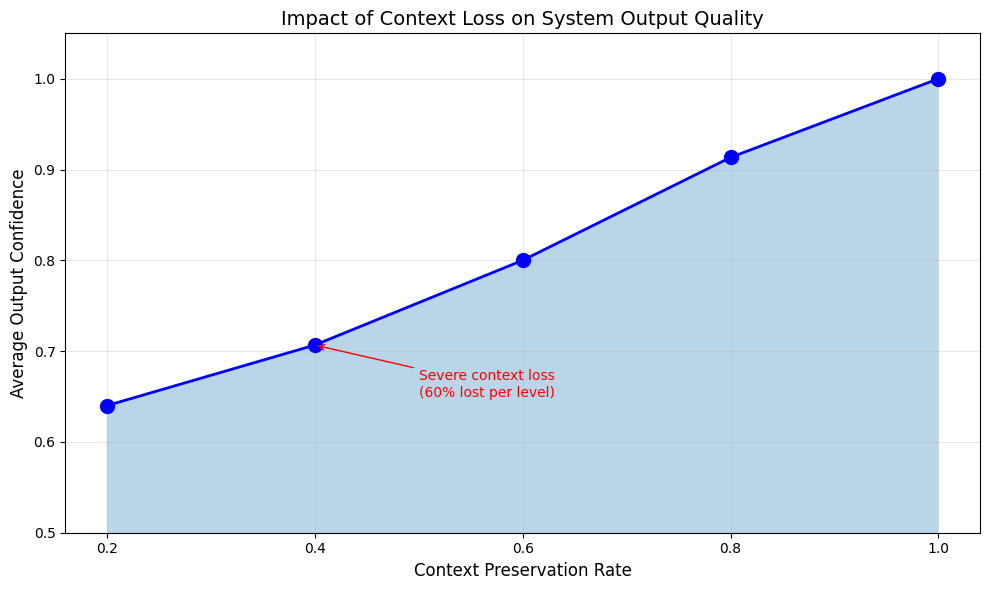


✅ Analysis complete! Graph saved as 'context_loss_analysis.png'


In [17]:
# ============================================================
# QUANTITATIVE ANALYSIS: Context Loss Impact
# ============================================================
import matplotlib.pyplot as plt

print("Running quantitative analysis...")

# Test different context preservation rates
preservation_rates = [0.2, 0.4, 0.6, 0.8, 1.0]
avg_confidences = []
num_trials = 5

for rate in preservation_rates:
    trial_confidences = []

    for trial in range(num_trials):
        # Build system with this preservation rate
        config = {
            'context_preservation': rate,
            'coordinator_timeout': 10.0,
            'worker_processing_time': 0.1,
            'verbose': False  # Quiet mode for batch testing
        }
        coordinator = build_research_system(config)

        task = Task(
            id=f"analysis-{rate}-{trial}",
            content="Compare environmental impact of EVs vs hydrogen fuel cells",
            context={
                "constraint_1": "Focus on past 3 years",
                "constraint_2": "Include manufacturing phase",
                "constraint_3": "Include operational phase",
                "constraint_4": "Include disposal phase",
                "constraint_5": "Cite peer-reviewed sources"
            },
            source="user"
        )

        result = asyncio.run(coordinator.process(task))
        trial_confidences.append(result.confidence)

    avg_conf = sum(trial_confidences) / len(trial_confidences)
    avg_confidences.append(avg_conf)
    print(f"Preservation rate {rate}: avg confidence = {avg_conf:.3f}")

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(preservation_rates, avg_confidences, 'bo-', linewidth=2, markersize=10)
plt.fill_between(preservation_rates, avg_confidences, alpha=0.3)
plt.xlabel('Context Preservation Rate', fontsize=12)
plt.ylabel('Average Output Confidence', fontsize=12)
plt.title('Impact of Context Loss on System Output Quality', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(preservation_rates)
plt.ylim(0.5, 1.05)

# Add annotation
plt.annotate('Severe context loss\n(60% lost per level)',
             xy=(0.4, avg_confidences[1]),
             xytext=(0.5, 0.65),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')

plt.tight_layout()
plt.savefig('context_loss_analysis.png', dpi=150)
plt.show()

print("\n✅ Analysis complete! Graph saved as 'context_loss_analysis.png'")

Running quantitative analysis...
Rate 0.2: confidence = 0.573
Rate 0.4: confidence = 0.740
Rate 0.6: confidence = 0.813
Rate 0.8: confidence = 0.920
Rate 1.0: confidence = 1.000


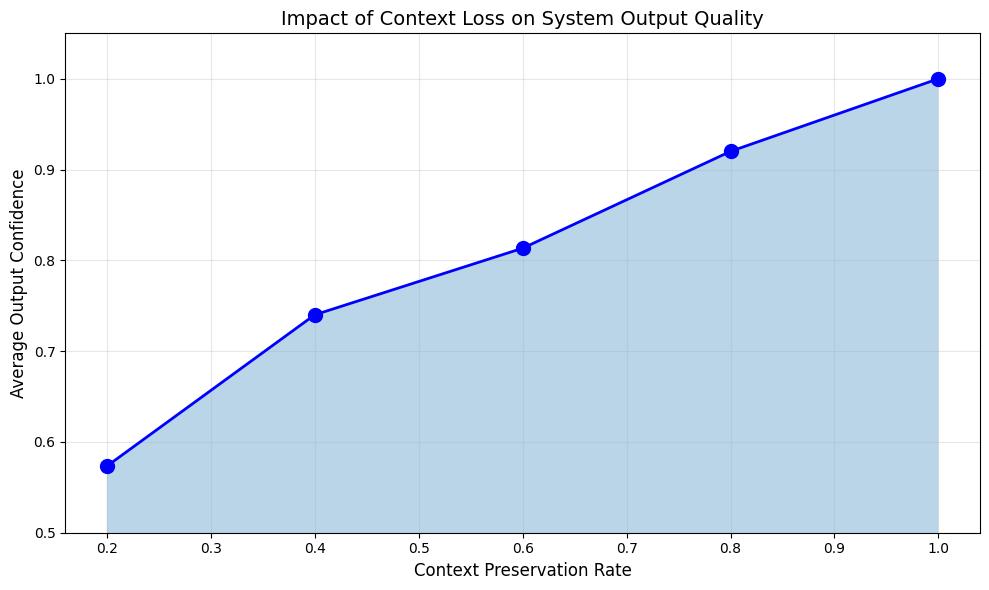

In [18]:
import matplotlib.pyplot as plt

print("Running quantitative analysis...")

preservation_rates = [0.2, 0.4, 0.6, 0.8, 1.0]
avg_confidences = []

for rate in preservation_rates:
    trial_confidences = []
    for trial in range(5):
        config = {
            'context_preservation': rate,
            'coordinator_timeout': 10.0,
            'worker_processing_time': 0.1,
            'verbose': False
        }
        coordinator = build_research_system(config)
        task = Task(
            id=f"analysis-{rate}-{trial}",
            content="Compare environmental impact of EVs vs hydrogen fuel cells",
            context={
                "constraint_1": "v1", "constraint_2": "v2", "constraint_3": "v3",
                "constraint_4": "v4", "constraint_5": "v5"
            },
            source="user"
        )
        result = asyncio.run(coordinator.process(task))
        trial_confidences.append(result.confidence)
    avg_confidences.append(sum(trial_confidences) / len(trial_confidences))
    print(f"Rate {rate}: confidence = {avg_confidences[-1]:.3f}")

plt.figure(figsize=(10, 6))
plt.plot(preservation_rates, avg_confidences, 'bo-', linewidth=2, markersize=10)
plt.fill_between(preservation_rates, avg_confidences, alpha=0.3)
plt.xlabel('Context Preservation Rate', fontsize=12)
plt.ylabel('Average Output Confidence', fontsize=12)
plt.title('Impact of Context Loss on System Output Quality', fontsize=14)
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 1.05)
plt.tight_layout()
plt.show()

---
# Summary

This notebook demonstrated:

1. **Normal Operation** - The system works correctly when properly configured

2. **Context Loss** - Information degrades through delegation chains when `context_preservation` is low

3. **Coordinator Bottleneck** - The system fails when workers take longer than the coordinator timeout

4. **Delegation Oscillation** - Tasks bounce between delegators when domain boundaries overlap

## Key Insight

**Architecture is the leverage point, not the model.** Each failure mode is caused by architectural decisions, not model limitations. Swapping GPT-4 for Claude or vice versa would not fix any of these failures—only changing the system architecture would.